In [1]:
#  feature: sepal length, sepal width, petal length, petal width
#  target: class label: setosa, versicolor, virginica

#  回顾: 机器学习项目的研发流程
#     1. 加载数据.
#     2. 数据的预处理.
#     3. 特征工程(提取, 预处理...)
#     4. 模型训练.
#     5. 模型评估.
#     6. 模型预测.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 加载数据

iris = load_iris()
# print(f"data:\n {iris}")
print(iris)
print(iris.data)
print(len(iris.data))
print(iris.target)
print(iris.feature_names)
print(iris.target_names)


{'data': array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
     

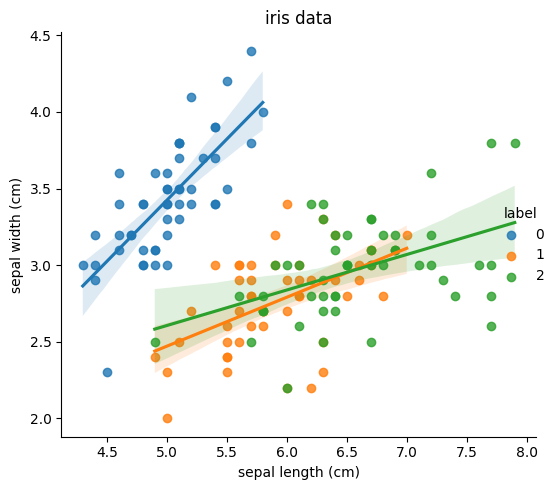

In [3]:
# 针对sepal length, sepal width, label 进行可视化

iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df['label'] = iris.target

sns.lmplot(data=iris_df, x='sepal length (cm)', y='sepal width (cm)', hue='label', fit_reg=True)

plt.title('iris data')
plt.tight_layout()
plt.show()

In [4]:
# 数据的切分

x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=13)

print(f"x_train:\n {x_train}, nums: {len(x_train)}")
print(f"x_test:\n {x_test}, nums: {len(x_test)}")
print(f"y_train:\n {y_train}, nums: {len(y_train)}")
print(f"y_test:\n {y_test}, nums: {len(y_test)}")



x_train:
 [[6.4 3.1 5.5 1.8]
 [5.2 4.1 1.5 0.1]
 [5.4 3.4 1.5 0.4]
 [6.9 3.1 5.1 2.3]
 [6.3 2.5 5.  1.9]
 [6.2 2.9 4.3 1.3]
 [5.1 3.3 1.7 0.5]
 [5.6 3.  4.5 1.5]
 [6.2 2.2 4.5 1.5]
 [4.8 3.  1.4 0.1]
 [5.2 3.5 1.5 0.2]
 [6.1 2.6 5.6 1.4]
 [5.7 2.9 4.2 1.3]
 [7.2 3.2 6.  1.8]
 [6.5 3.2 5.1 2. ]
 [7.2 3.6 6.1 2.5]
 [5.1 3.4 1.5 0.2]
 [5.  2.3 3.3 1. ]
 [4.4 3.2 1.3 0.2]
 [6.5 2.8 4.6 1.5]
 [5.7 3.8 1.7 0.3]
 [5.7 3.  4.2 1.2]
 [5.9 3.2 4.8 1.8]
 [6.8 3.2 5.9 2.3]
 [4.9 3.1 1.5 0.1]
 [5.5 2.4 3.8 1.1]
 [4.7 3.2 1.6 0.2]
 [5.6 2.5 3.9 1.1]
 [6.4 2.7 5.3 1.9]
 [6.3 3.3 6.  2.5]
 [4.6 3.1 1.5 0.2]
 [5.  3.5 1.6 0.6]
 [6.3 2.9 5.6 1.8]
 [6.3 3.3 4.7 1.6]
 [7.3 2.9 6.3 1.8]
 [6.5 3.  5.5 1.8]
 [5.  3.6 1.4 0.2]
 [4.9 2.5 4.5 1.7]
 [5.  2.  3.5 1. ]
 [6.7 3.  5.  1.7]
 [5.3 3.7 1.5 0.2]
 [5.4 3.4 1.7 0.2]
 [5.  3.2 1.2 0.2]
 [7.  3.2 4.7 1.4]
 [4.9 2.4 3.3 1. ]
 [5.8 2.7 4.1 1. ]
 [6.7 2.5 5.8 1.8]
 [7.6 3.  6.6 2.1]
 [5.5 2.3 4.  1.3]
 [5.9 3.  5.1 1.8]
 [5.6 2.8 4.9 2. ]
 [6.  2.2 5.  1.5]
 [

In [5]:
# pipeline: 加载数据，数据处理，特征工程，模型训练，模型预测，模型评估

def iris_eval_test():
    # 加载数据
    iris = load_iris()

    # 数据预处理
    x_train, x_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=13)

    # 特征工程
    transfer = StandardScaler()
    x_train = transfer.fit_transform(x_train)
    x_test = transfer.transform(x_test)

    # 模型训练
    estimator = KNeighborsClassifier()
    estimator.fit(x_train, y_train)

    # 模型预测
    y_pred = estimator.predict(x_test)
    y_pred_proba = estimator.predict_proba(x_test)

    # 模型评估
    print(f"acc1: {estimator.score(x_test, y_test)}")
    print(f"acc2: {accuracy_score(y_pred, y_test)}")
    print(f'y_pred_proba:\n {y_pred_proba}')

iris_eval_test()
    

acc1: 0.9666666666666667
acc2: 0.9666666666666667
y_pred_proba:
 [[0.  1.  0. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  0.2 0.8]
 [0.  0.  1. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  0.4 0.6]
 [1.  0.  0. ]
 [0.  1.  0. ]
 [0.  0.4 0.6]
 [0.  0.6 0.4]
 [0.  0.8 0.2]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [1.  0.  0. ]
 [0.  0.2 0.8]
 [0.  0.  1. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [0.  1.  0. ]
 [1.  0.  0. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  1.  0. ]
 [0.  0.  1. ]
 [1.  0.  0. ]
 [0.  0.  1. ]
 [0.  1.  0. ]
 [0.  0.  1. ]]


In [6]:
# 网格搜索，交叉验证

from sklearn.model_selection import GridSearchCV

estimator = KNeighborsClassifier()
param_dict = {'n_neighbors': [i for i in range(1, 11)]}
estimator = GridSearchCV(estimator, param_dict, cv=4)
estimator.fit(x_train, y_train)

y_pred = estimator.predict(x_test)
print(f'acc: {accuracy_score(y_test, y_pred)}')


acc: 0.9
